In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import classification_report


In [58]:
import warnings
warnings.filterwarnings("ignore")

In [8]:
data = load_iris()
df=pd.DataFrame(data.data,columns=data.feature_names)
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [18]:
X=pd.DataFrame(data.data,columns=data.feature_names)
y=pd.Series(data.target,name='target')



In [19]:
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3
149,5.9,3.0,5.1,1.8


In [20]:
df.shape


(150, 4)

In [21]:
df.columns


Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='object')

In [22]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [23]:
df.duplicated().sum()


np.int64(1)

In [24]:
df.drop_duplicates()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


<Axes: >

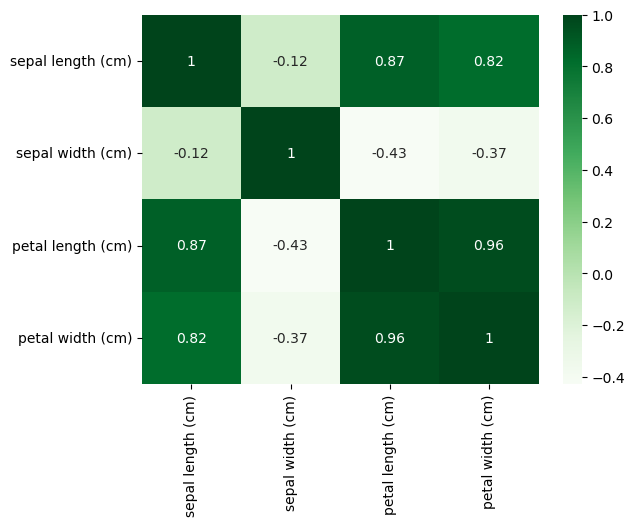

In [26]:
df.corr()
sns.heatmap(df.corr(),annot=True,cmap='Greens')

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.4, random_state=42)

In [39]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [41]:
knn = KNeighborsClassifier(n_neighbors=5)

In [43]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [44]:
y_pred = knn.predict(X_test)

In [48]:
print("Accuracy", accuracy_score(y_test, y_pred))
print("\n Classification Report", classification_report(y_test,y_pred))

Accuracy 0.9833333333333333

 Classification Report               precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       0.95      1.00      0.97        19
           2       1.00      0.94      0.97        18

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60



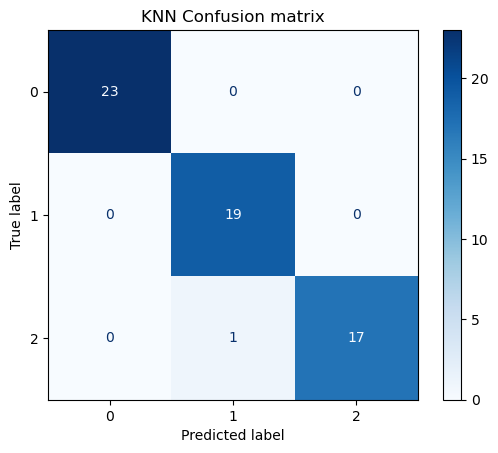

In [56]:
cm = confusion_matrix(y_test, y_pred)

labels = np.unique(y_test)

disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = labels)
disp.plot(cmap="Blues")
plt.title("KNN Confusion matrix")
plt.show()

In [59]:
sepal_length = float(input("Enter Sepal Length:"))
sepal_width = float(input("Enter Sepal Width:"))
petal_length = float(input("Enter Petal Length:"))
petal_width = float(input("Enter Petal Width:"))

new_flower = [[sepal_length, sepal_width, petal_length, petal_width]]

new_flower_scaled = scaler.transform(new_flower)

prediction = knn.predict(new_flower_scaled)

print("\nPredicted Flower Species:", data.target_names[prediction[0]])

Enter Sepal Length: 5
Enter Sepal Width: 6
Enter Petal Length: 7
Enter Petal Width: 9



Predicted Flower Species: virginica
